PART A: DATA PREPARATION

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans

In [952]:
file_path = "StudentPerformanceFactors.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "lainguyn123/student-performance-factors",
  file_path,
)

/var/folders/yb/qcdwjb5s7_s4nm_tggy7c_nm0000gn/T/ipykernel_65453/571402326.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [953]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [954]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [955]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [956]:
print("=== Categorical Columns ===")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{df[col].value_counts()}")

=== Categorical Columns ===

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

School_Type
Public     4598
Private    2009
Name: count, dtype: int64

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

Distance_from_Home
Near   

In [957]:
# Check for missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

# Check for duplicates
print("\n=== Duplicate Rows ===")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

=== Missing Values ===
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

=== Duplicate Rows ===
Number of duplicate rows: 0


In [958]:
# Fill Missing Values with mode for categorical columns
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0])

In [959]:
# Check for missing values after cleaning
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

=== Missing Values ===
No missing values found.


In [960]:
# Identify all numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Columns to check for outliers:", num_cols)

Columns to check for outliers: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


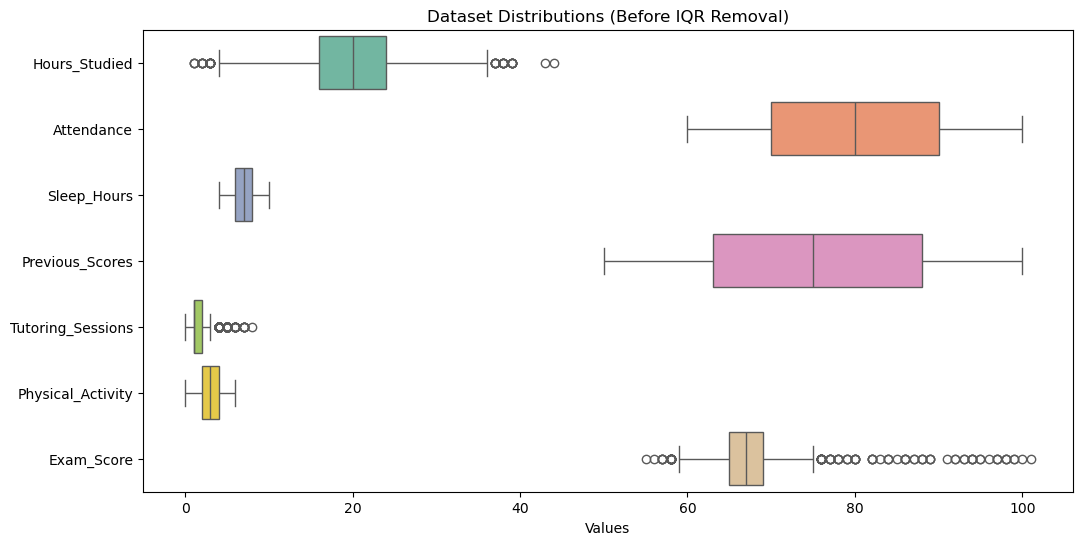

In [961]:
# Visualize the dataset before removing outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient="h", palette="Set2")
plt.title("Dataset Distributions (Before IQR Removal)")
plt.xlabel("Values")
plt.show()

In [962]:
# Apply selective IQR method to remove outliers
df_cleaned = df.copy()

for col in num_cols:
    multiplier = 1.5

    # Use higher multiplier to only filter extreme outliers for Exam_Score
    if col == "Exam_Score":
        multiplier = 2.0  

    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (multiplier * IQR)
    upper_bound = Q3 + (multiplier * IQR)
    
    df_cleaned = df_cleaned[
        (df_cleaned[col] >= lower_bound) & 
        (df_cleaned[col] <= upper_bound)
    ]

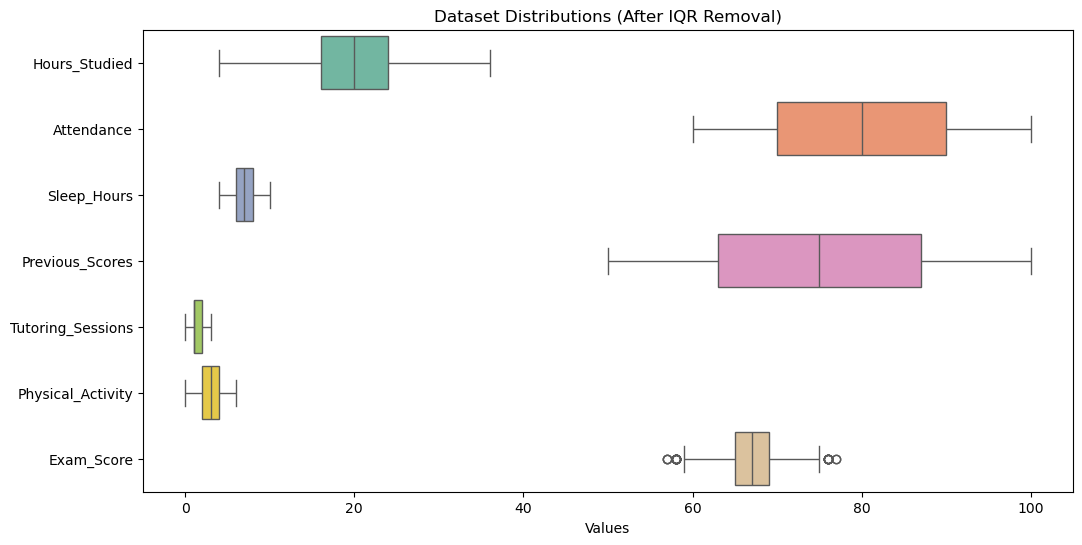

=== Outlier Removal Summary ===
Original dataset rows: 6607
Cleaned dataset rows:  6086
Total rows removed:    521


In [963]:
# Visualize the dataset after cleanup and print a summary of the outlier removal process
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned[num_cols], orient="h", palette="Set2")
plt.title("Dataset Distributions (After IQR Removal)")
plt.xlabel("Values")
plt.show()

print("=== Outlier Removal Summary ===")
print(f"Original dataset rows: {df.shape[0]}")
print(f"Cleaned dataset rows:  {df_cleaned.shape[0]}")
print(f"Total rows removed:    {df.shape[0] - df_cleaned.shape[0]}")

In [964]:
# Separate target variable and features
TARGET = "Exam_Score"

# Drop target from features
features = df_cleaned.drop(columns=[TARGET])
target = df_cleaned[TARGET]

print("Target variable:", TARGET)
print("Number of features:", features.shape[1])
print("Feature columns:", features.columns.tolist())

Target variable: Exam_Score
Number of features: 19
Feature columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [965]:
# Identify categorical columns
cat_cols = features.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Apply One-Hot Encoding
features_encoded = pd.get_dummies(features, columns=cat_cols, drop_first=True)

# Apply Standard Scaling
scaler = StandardScaler()
features_scaled_array = scaler.fit_transform(features_encoded)

# Convert back to DataFrame
features_final = pd.DataFrame(
    features_scaled_array, 
    columns=features_encoded.columns
)

print("New shape after encoding:", features_final.shape)
features_final.head()

Categorical columns to encode: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
New shape after encoding: (6086, 27)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,0.515668,0.351411,-0.023491,-0.146183,-1.312599,0.038907,2.000205,-1.022938,-0.498408,-1.005272,...,0.806638,0.660344,-0.804697,1.227432,-0.339808,0.995410,-0.497894,-0.659575,0.820864,0.856970
1,-0.172530,-1.382566,0.657311,-1.121546,0.719834,1.009362,2.000205,-1.022938,-0.498408,0.994756,...,0.806638,0.660344,-0.804697,-0.814709,-0.339808,-1.004611,-0.497894,1.516128,-1.218229,-1.166902
2,0.687717,1.565195,-0.023491,1.107855,0.719834,1.009362,-0.499949,0.977576,-0.498408,0.994756,...,0.806638,0.660344,1.242704,-0.814709,-0.339808,-1.004611,2.008460,-0.659575,0.820864,0.856970
3,1.547965,0.784905,0.657311,1.595536,-0.296382,1.009362,2.000205,-1.022938,-0.498408,0.994756,...,0.806638,0.660344,-0.804697,-0.814709,-0.339808,0.995410,-0.497894,1.516128,-1.218229,0.856970
4,-0.172530,1.045002,-0.704294,-0.703533,1.736050,1.009362,-0.499949,0.977576,-0.498408,0.994756,...,-1.239714,0.660344,1.242704,-0.814709,-0.339808,-1.004611,-0.497894,-0.659575,0.820864,-1.166902


In [966]:
# For Supervised Learning (Regression)
X_regression = features_final.copy()
Y_regression = target.copy()

# For Unsupervised Learning (Clustering)
X_clustering = features_final.copy() 

In [980]:
data_desc = """
DATA DESCRIPTION:
The dataset is synthetically generated (sourced from Kaggle: lainguyn123/student-performance-factors). 
It contains 20 academic and socio-economic attributes across 6,607 student records. 
The target variable for regression is Exam_Score (numerical). Key features include 
study habits (Hours_Studied, Tutoring_Sessions), environmental factors 
(Internet_Access, Family_Income, Teacher_Quality), and personal metrics 
(Motivation_Level, Physical_Activity).

PREPROCESSING STEPS:
1. Missing Values: 235 missing entries in 'Teacher_Quality', 'Parental_Education_Level', 
   and 'Distance_from_Home' were imputed using the Mode (most frequent value).
2. Duplicate Check: Verified dataset for identical records; no duplicates were found.
3. Categorical Encoding: Nominal and ordinal variables were transformed using 
   One-Hot Encoding, expanding the feature space to allow the model to capture 
   non-linear relationships between categorical states.
4. Outlier Removal (Selective IQR): A standard 1.5x IQR was applied to features, 
   while a wider 2.0x IQR was applied specifically to 'Exam_Score'. This preserved 
   genuine high/low achieving "signal" while filtering out extreme synthetic noise.
5. Scaling: StandardScaler was applied to all numerical features to normalize 
   distributions, which is critical for the K-Means clustering in Part C.
"""

print(data_desc)
print("-" * 50)
print(f"Target Variable:      Exam_Score")
# num_features list will now likely be longer due to One-Hot Encoding
print(f"Total Features:       {len(features_final.columns)} (Expanded via One-Hot Encoding)")
print("-" * 50)
print(f"Original Row Count:   6,607")
print(f"Final Row Count:      {df_cleaned.shape[0]} (Retained: {round(df_cleaned.shape[0] / 6607 * 100, 2)}%)")
print(f"Rows Removed:         {6607 - df_cleaned.shape[0]}")


DATA DESCRIPTION:
The dataset is synthetically generated (sourced from Kaggle: lainguyn123/student-performance-factors). 
It contains 20 academic and socio-economic attributes across 6,607 student records. 
The target variable for regression is Exam_Score (numerical). Key features include 
study habits (Hours_Studied, Tutoring_Sessions), environmental factors 
(Internet_Access, Family_Income, Teacher_Quality), and personal metrics 
(Motivation_Level, Physical_Activity).

PREPROCESSING STEPS:
1. Missing Values: 235 missing entries in 'Teacher_Quality', 'Parental_Education_Level', 
   and 'Distance_from_Home' were imputed using the Mode (most frequent value).
2. Duplicate Check: Verified dataset for identical records; no duplicates were found.
3. Categorical Encoding: Nominal and ordinal variables were transformed using 
   One-Hot Encoding, expanding the feature space to allow the model to capture 
   non-linear relationships between categorical states.
4. Outlier Removal (Selective IQ

PART B: SUPERVISED LEARNING (REGRESSION)

In [968]:
X_regression.shape, Y_regression.shape

((6086, 27), (6086,))

In [969]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_regression, Y_regression, test_size=0.2, random_state=1)

In [970]:
X_train.shape, Y_train.shape

((4868, 27), (4868,))

In [971]:
X_test.shape, Y_test.shape

((1218, 27), (1218,))

In [972]:
def evaluate_model(model):
    model.fit(X_train, Y_train)
    preds = model.predict(X_test) # Predict once to save time
    train_preds = model.predict(X_train) # Predict on training set for R^2 calculation

    print("=== Model Evaluation ===")
    print("Mean Absolute Error:", mean_absolute_error(Y_test, preds))
    print("Mean Squared Error:", mean_squared_error(Y_test, preds))
    print("R^2 Score:", r2_score(Y_test, preds))

    print("\n=== Training Set R^2 Score ===")
    print("R^2 Score on Training Set:", r2_score(Y_train, train_preds))

In [973]:
linear_model = LinearRegression()
evaluate_model(linear_model)
print("\nCoefficients:", linear_model.coef_)
print("Intercept:", linear_model.intercept_)

=== Model Evaluation ===
Mean Absolute Error: 0.2775904805897903
Mean Squared Error: 0.1107590805684899
R^2 Score: 0.9902024936149344

=== Training Set R^2 Score ===
R^2 Score on Training Set: 0.9900748444603901

Coefficients: [ 1.73269574e+00  2.30562801e+00  2.24967896e-02  7.06413744e-01
  4.91791311e-01  2.46986283e-01 -7.95346900e-01 -5.01772008e-01
 -7.99377642e-01 -4.87029502e-01  2.48353738e-01 -4.64174093e-01
 -2.53254709e-01  2.67936761e-01 -4.81138732e-01 -2.38928636e-01
 -3.00374520e-01 -2.45835662e-01  7.82541351e-04  2.45323740e-01
  4.91150732e-01 -3.05385856e-01 -2.42322406e-01  2.10575104e-01
  2.32747780e-01  4.93802375e-01 -3.08732045e-04]
Intercept: 66.96389655922579


In [974]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=0.001)
evaluate_model(ridge_model)

=== Model Evaluation ===
Mean Absolute Error: 0.2775904854533303
Mean Squared Error: 0.11075909379556012
R^2 Score: 0.9902024924448967

=== Training Set R^2 Score ===
R^2 Score on Training Set: 0.99007484446032


In [975]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.001)
evaluate_model(lasso_model)

=== Model Evaluation ===
Mean Absolute Error: 0.27747569059685984
Mean Squared Error: 0.11066198878562682
R^2 Score: 0.9902110821420119

=== Training Set R^2 Score ===
R^2 Score on Training Set: 0.990069896722946


In [976]:
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet(alpha=0.001)
evaluate_model(elastic_model)

=== Model Evaluation ===
Mean Absolute Error: 0.2775589558162169
Mean Squared Error: 0.11075051993222015
R^2 Score: 0.9902032508701236

=== Training Set R^2 Score ===
R^2 Score on Training Set: 0.9900720400156531


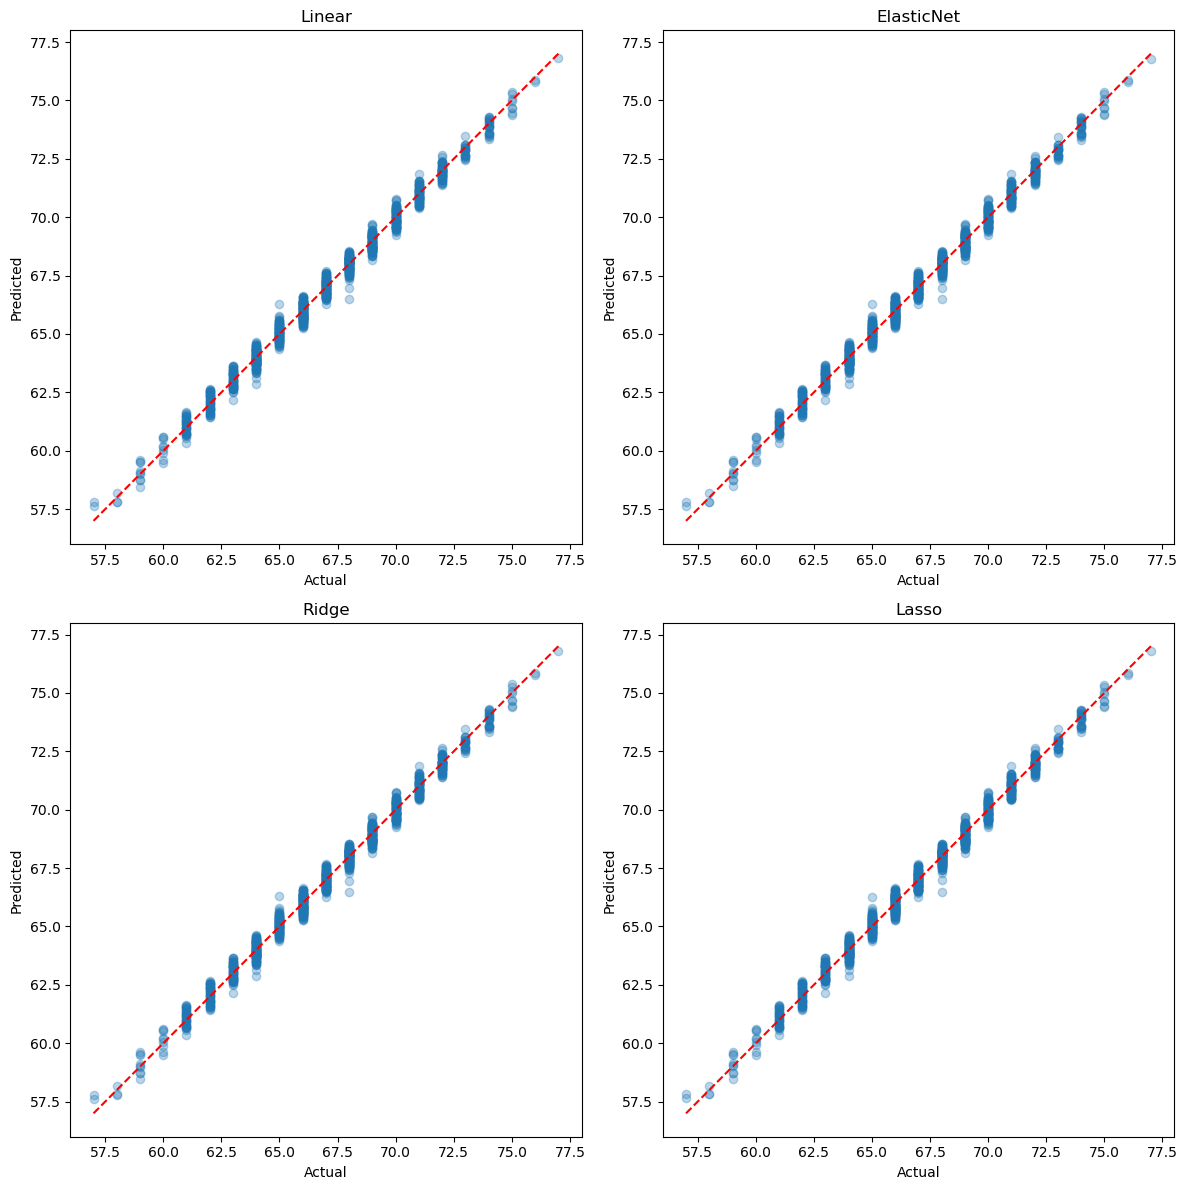

In [977]:
import matplotlib.pyplot as plt

models = {
    'Linear': linear_model,
    'ElasticNet': elastic_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model
}

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten() 

for ax, (name, model) in zip(axes, models.items()):
    Y_pred = model.predict(X_test)
    ax.scatter(Y_test, Y_pred, alpha=0.3)
    ax.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # perfect prediction line
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(name)

plt.tight_layout()
plt.show()

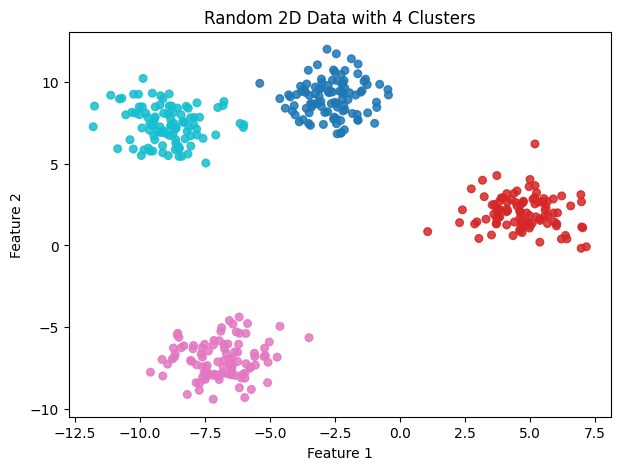

Shape of X: (400, 2)
Unique cluster labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [17]:
X, y = make_blobs(
    n_samples=n_samples,
    centers=n_clusters,
    n_features=2,
    cluster_std=1.1,
    random_state=random_state,
)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="tab10", s=30, alpha=0.85)
plt.title(f"Random 2D Data with {n_clusters} Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Shape of X:", X.shape)
print("Unique cluster labels:", sorted(set(y)))

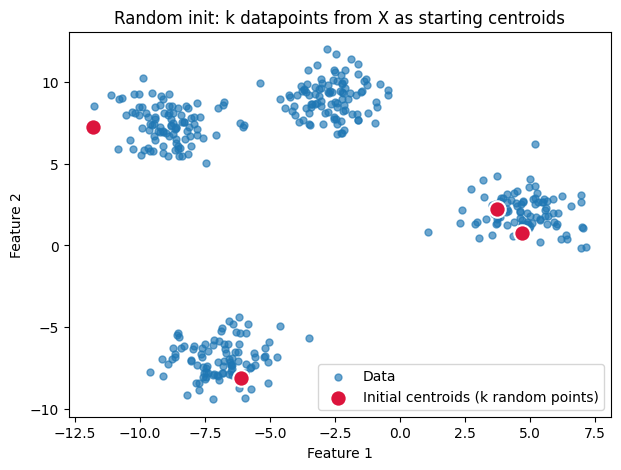

c:\Users\earlc\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,n_clusters,4
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [18]:
rng = np.random.default_rng(random_state)
init_indices = rng.choice(X.shape[0], size=n_clusters, replace=False)
initial_centroids = X[init_indices]

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=25, alpha=0.65, label="Data")
plt.scatter(
    initial_centroids[:, 0],
    initial_centroids[:, 1],
    c="crimson",
    marker="o",
    s=140,
    linewidths=1.5,
    edgecolors="white",
    label="Initial centroids (k random points)",
)
plt.legend()
plt.title("Random init: k datapoints from X as starting centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Same idea via sklearn: init="random" picks k distinct rows from X (up to sklearn version)
kmeans_random = KMeans(
    n_clusters=n_clusters,
    init="random",
    n_init=10,
    random_state=random_state,
)
kmeans_random.fit(X)

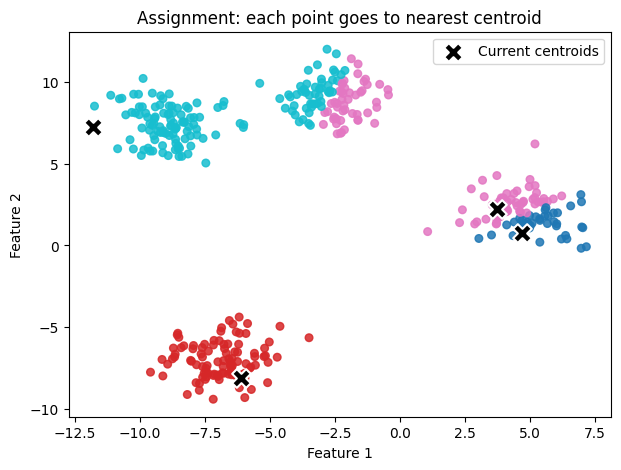

Cluster counts after assignment: [ 44 100 105 151]


In [19]:
# Assignment step: assign each datapoint to the nearest centroid
# distances shape: (n_samples, n_clusters)
distances = np.linalg.norm(X[:, np.newaxis, :] - initial_centroids[np.newaxis, :, :], axis=2)
cluster_labels = np.argmin(distances, axis=1)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap="tab10", s=30, alpha=0.85)
plt.scatter(
    initial_centroids[:, 0],
    initial_centroids[:, 1],
    c="black",
    marker="X",
    s=180,
    linewidths=1.5,
    edgecolors="white",
    label="Current centroids",
)
plt.title("Assignment: each point goes to nearest centroid")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

print("Cluster counts after assignment:", np.bincount(cluster_labels, minlength=n_clusters))

Centroid shift per cluster: [0.89090911 1.3714407  3.9943805  4.81916182]
Max shift: 4.819161818347273


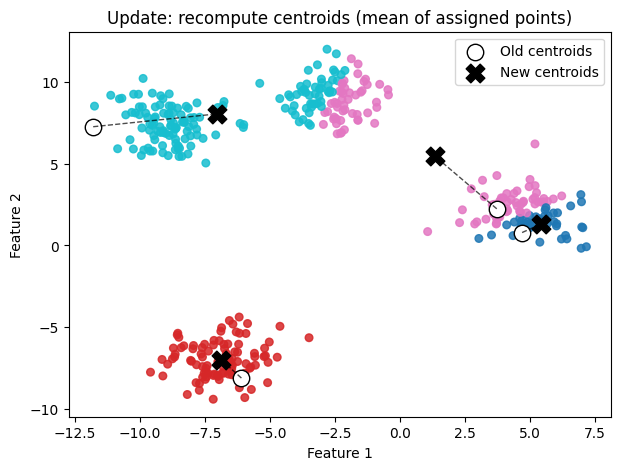

In [20]:
# Update step: compute new centroids as the mean of assigned points
new_centroids = initial_centroids.copy()

for j in range(n_clusters):
    points_in_cluster = X[cluster_labels == j]
    if len(points_in_cluster) == 0:
        # If a cluster is empty, re-seed its centroid to a random datapoint
        new_centroids[j] = X[rng.integers(0, X.shape[0])]
    else:
        new_centroids[j] = points_in_cluster.mean(axis=0)

shift = np.linalg.norm(new_centroids - initial_centroids, axis=1)
print("Centroid shift per cluster:", shift)
print("Max shift:", shift.max())

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap="tab10", s=30, alpha=0.85)
plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1], c="white", edgecolors="black", marker="o", s=140, label="Old centroids")
plt.scatter(new_centroids[:, 0], new_centroids[:, 1], c="black", marker="X", s=180, label="New centroids")
for j in range(n_clusters):
    plt.plot(
        [initial_centroids[j, 0], new_centroids[j, 0]],
        [initial_centroids[j, 1], new_centroids[j, 1]],
        "k--",
        linewidth=1,
        alpha=0.7,
    )
plt.title("Update: recompute centroids (mean of assigned points)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# Set up for the next iteration (optional)
initial_centroids = new_centroids

In [22]:
# Convergence check: stop if centroid movement is below tolerance
tol = 1e-4
max_shift = shift.max()
converged = max_shift < tol

print(f"Tolerance: {tol}")
print(f"Max centroid shift: {max_shift:.8f}")
print("Converged?", converged)

if converged:
    print("Convergence criterion met: stop iterations.")
else:
    print("Not converged yet: continue assignment + update steps.")

Tolerance: 0.0001
Max centroid shift: 4.81916182
Converged? False
Not converged yet: continue assignment + update steps.


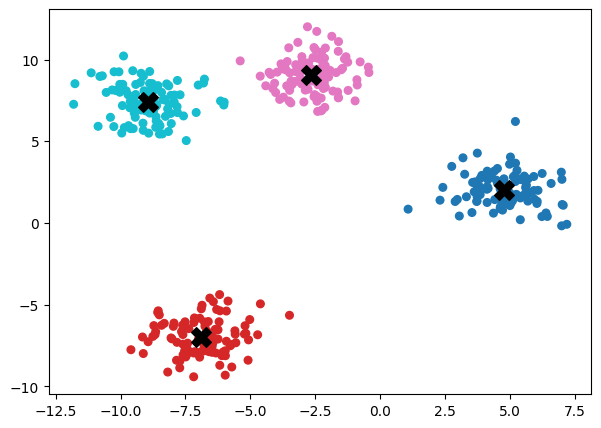

In [24]:
max_iter = 100
tol = 1e-4
rng = np.random.default_rng(42)
centroids = X[rng.choice(X.shape[0], n_clusters, replace=False)]

for _ in range(max_iter):
    d = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = np.argmin(d, axis=1)

    new_centroids = np.array([
        X[labels == i].mean(axis=0) if np.any(labels == i) else centroids[i]
        for i in range(n_clusters)
    ])

    if np.max(np.linalg.norm(new_centroids - centroids, axis=1)) < tol:
        centroids = new_centroids
        break

    centroids = new_centroids

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=30)
plt.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=200)
plt.show()

In [25]:
d = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
labels_check = np.argmin(d, axis=1)

centroids_check = np.array([
    X[labels_check == i].mean(axis=0) if np.any(labels_check == i) else centroids[i]
    for i in range(n_clusters)
])

max_shift = np.max(np.linalg.norm(centroids_check - centroids, axis=1))
converged = max_shift < tol

print("max_shift:", max_shift)
print("converged:", converged)

max_shift: 0.0
converged: True
